<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-I/blob/main/sistemas_de_linea_de_espera_con_dos_servidores_en_serie_y_paralelo_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#SISTEMAS MEDIANTE EVENTOS DISCRETOS

##Sistemas de línea de espera con dos servidores en serie

**Nombre**: Karla Michelle Soriano Sánchez  

**Instrucción**: Programar en Jupyter Notebook el seudocódigo propuesto por Sheldon Ross para un sistema de línea de espera con dos servidores en serie.

Como prueba utilizar:
$
\lambda = 4
$
y
$
\mu = 6.
$

Comentar y documentar el código. Analizar los resultados obtenidos mediante simulación.

**Objetivo**: Implementar mediante simulación por eventos discretos un sistema de línea de espera con dos servidores en serie siguiendo el algoritmo propuesto por Sheldon Ross.


###Fundamento teórico

**Sistema de línea de espera con dos servidores en serie**

En este sistema cada cliente debe recibir servicio en dos etapas consecutivas.

Primero es atendido por el servidor 1, después pasa al servidor 2 y finalmente abandona el sistema.

El esquema general es

$$
\text{Llegadas}
\rightarrow
\text{Servidor 1}
\rightarrow
\text{Servidor 2}
\rightarrow
\text{Salida}.
$$

Este tipo de sistema también se conoce como cola en tándem o secuencial.

**Distribuciones utilizadas**

Las llegadas siguen un proceso de Poisson con tasa
$
\lambda,
$
por lo que los tiempos entre llegadas se modelan mediante una distribución exponencial:
$
T \sim Exp(\lambda).
$

Los tiempos de servicio de ambos servidores también se consideran exponenciales con parámetro
$
\mu.
$

**Variable de tiempo**

La simulación se desarrolla mediante una variable de tiempo
$
t,
$
la cual representa el instante actual del sistema.

Cada vez que ocurre un evento, el reloj de simulación avanza hasta el tiempo asociado a dicho evento.

**Estado del sistema**

Se define el estado del sistema mediante el par ordenado

$$
(n_1,n_2),
$$

donde:

- $n_1$ representa el número de clientes asociados al servidor 1.
- $n_2$ representa el número de clientes asociados al servidor 2.

Estos valores incluyen tanto a los clientes que están siendo atendidos como a aquellos que esperan en la fila correspondiente.

**Variables de conteo**

$N_A$ : Número de llegadas registradas hasta el instante $t$.

$N_D$ :  Número de clientes que han abandonado completamente el sistema hasta el instante $t$.

**Variables de salida**

Para cada cliente se almacenarán los instantes más importantes de su recorrido dentro del sistema.
Dado $n \geq 1$

$
A_1(n)
$
 : Hora de llegada del cliente $n$ al sistema.

$
A_2(n)
$
 : Hora de llegada del cliente $n$ al servidor 2.

$
D(n)
$
 : Hora de salida del cliente $n$ del sistema.

**Lista de eventos**

La simulación se basa en una lista de eventos formada por

$$
(t_A,t_1,t_2),
$$

donde:

- $t_A$ es el instante (hora)  de la próxima llegada.
- $t_1$ es el instante en que finalizará el servicio actualmente en el servidor 1.
- $t_2$ es el instante en que finalizará el servicio actualmente en el servidor 2.

En cada iteración se selecciona el menor de estos tiempos para determinar el siguiente evento.

**Eventos posibles**

De acuerdo con el algoritmo de Ross, pueden ocurrir tres tipos de eventos.

- Evento 1: Llegada de un cliente.
 Ocurre cuando

$$
t_A=\min(t_A,t_1,t_2).
$$
En este caso un nuevo cliente entra al sistema y se actualizan las variables correspondientes.

- Evento 2: Salida del servidor 1. Ocurre cuando

$$
t_1<t_A
$$

y

$$
t_1\le t_2.
$$
El cliente termina su servicio en el servidor 1 y pasa al servidor 2.


- Evento 3: Salida del servidor 2. Ocurre cuando

$$
t_2<t_A
$$

y

$$
t_2<t_1.
$$

El cliente concluye su servicio en el servidor 2 y abandona el sistema.

In [461]:
import numpy as np
import random as r
from tabulate import tabulate
from dataclasses import dataclass
import matplotlib.pyplot as plt

**Estado del sistema**

Durante la simulación es necesario conocer en todo momento la situación actual de la línea de espera.

Para ello se define una estructura que almacena:

- El número de clientes asociados al servidor 1.
- El número de clientes asociados al servidor 2.
- El número total de llegadas registradas.
- El número total de salidas registradas.
- El tiempo actual de simulación.

Agrupar estas variables en una sola estructura facilita la actualización del sistema cada vez que ocurre un evento.

In [462]:
@dataclass
class EstadoSistema:
    n1: int = 0
    n2: int = 0

    NA: int = 0
    ND: int = 0

    t: float = 0.0


**Generación de tiempos aleatorios**

Se implementaran funciones auxiliares que permitan generar:

- tiempos entre llegadas;
- tiempos de servicio del servidor 1;
- tiempos de servicio del servidor 2.


In [463]:
# Generar tiempo entre llegadas

def generar_llegada(lamda):

  # Generar variable exponencial
  return np.random.exponential(1 / lamda)

In [464]:
# Generar tiempo de servicio

def generar_servicio1(mu):
  return np.random.exponential(1 / mu)

def generar_servicio2(mu):
  return np.random.exponential(1 / mu)

*Inicialización del sistema*

La simulación comienza con que  no existen clientes dentro del sistema, por lo que

$
N_A=N_D=0
$
y
$
(n_1,n_2)=(0,0)
$

Posteriormente se genera el primer tiempo entre llegadas
$
T_0
$
y se construye la lista inicial de eventos

$$
t_A=T_0,
\qquad
t_1=t_2=\infty.
$$

Además, se crean las estructuras donde se almacenarán las horas de llegada y salida de cada cliente.

In [465]:
# Inicialización del sistema

def inicializar(lamb):
    """
    Inicializa las variables del sistema.
    """

    # Crear el estado inicial del sistema
    estado = EstadoSistema()

    # Programar la primera llegada
    tA = generar_llegada(lamb)


    # Inicialmente no hay clientes en servicio,
    # por lo que los tiempos de salida se consideran infinitos
    t1 = np.inf
    t2 = np.inf

    return estado, tA, t1, t2

*Caso 1: Llegada de un cliente*

Este evento ocurre cuando

$$
t_A=\min(t_A,t_1,t_2).
$$

En este caso el reloj de simulación avanza hasta el instante
$
t=t_A.
$

Posteriormente se actualizan las variables de conteo y de estado:

$
N_A=N_A+1
\quad $ y
$\quad n_1=n_1+1.
$

Posteriormente se programa la siguiente llegada al sistema
Si el servidor 1 estaba vacío, se genera un tiempo de servicio y se programa la correspondiente salida.

Finalmente se registra

$$
A_1(N_A)=t.
$$



In [466]:
# Caso 1: Llegada al sistema

def evento_llegada(estado, tA, t1, t2, lamb, mu1, A1):
    """
    Procesa una llegada al sistema.
    """

    # Actualizar el reloj de simulación
    estado.t = tA

    # Registrar una nueva llegada
    estado.NA += 1

    # Incrementar el número de clientes asociados al servidor 1

    estado.n1 += 1

    # Identificador del cliente que acaba de llegar
    cliente = estado.NA

    # Registrar la hora de llegada al sistema
    A1[cliente] = estado.t

    # Programar la siguiente llegada
    tA = estado.t + generar_llegada(lamb)

    # Si el servidor 1 estaba vacío, el cliente entra inmediatamente a servicio
    if estado.n1 == 1:

        y1 = generar_servicio1(mu1)

        t1 = estado.t + y1

    return tA, t1, t2

*Caso 2: Salida del servidor 1*

Esto sucede cuando

$
t_1<t_A \quad
$
y
$
\quad t_1\le t_2.
$

En este instante el cliente abandona el servidor 1 y pasa al servidor 2, por lo que:

$
n_1=n_1-1 \quad
$
y
$
\quad n_2=n_2+1
$

Si aún existen clientes asociados al servidor 1, se programa la siguiente salida de dicho servidor.

Si el servidor 2 estaba vacío, se genera un tiempo de servicio y se programa su correspondiente salida.

Finalmente se registra
$
A_2(N_A-n_1)=t
$

In [467]:
# Caso 2: Salida del servidor 1

def evento_servidor1(estado, tA, t1, t2, mu1, mu2, A2):
    """
    Cliente termina servicio en servidor 1.
    """

    # Actualizar el reloj de simulación
    estado.t = t1

    # El cliente abandona el servidor
    estado.n1 -= 1

    # El cliente entra al servidor 2
    estado.n2 += 1

    # Actualizar el estado del servidor 1
    if estado.n1 == 0:

        # No quedan clientes en el servidor 1
        t1 = np.inf

    else:

        # Programar la siguiente terminación de servicio
        y1 = generar_servicio1(mu1)

        t1 = estado.t + y1

    # Actualizar el estado del servidor 2
    if estado.n2 == 1:

        # El servidor 2 estaba vacío,
        # por lo que inicia servicio inmediatamente
        y2 = generar_servicio2(mu2)

        t2 = estado.t + y2

    # Identificar al cliente que llega al servidor 2
    cliente = estado.NA - estado.n1

    # Registrar la hora de llegada al servidor 2

    A2[cliente] = estado.t

    return tA, t1, t2

*Caso 3: Salida del servidor 2*

Esto sucede cuando

$
t_2<t_A
\quad $
y
$\quad
t_2<t_1
$


Siguiendo el algoritmo de Ross, el cliente abandona el sistema, por lo que

$
N_D=N_D+1 \quad
$
y
$ \quad
n_2=n_2-1.
$

Si aún existen clientes asociados al servidor 2, se genera un nuevo tiempo de servicio y se programa la siguiente salida.

Finalmente se registra

$$
D(N_D)=t.
$$

In [468]:
# Caso 3: Salida del servidor 2

def evento_servidor2(estado, tA, t1, t2, mu2, D):
    """
    Cliente termina servicio en servidor 2.
    """

    # Actualizar el reloj de simulación
    estado.t = t2

    # Registrar una salida del sistema
    estado.ND += 1

    # El cliente abandona el servidor 2
    estado.n2 -= 1

    # Registrar el instante de salida
    D[estado.ND] = estado.t

    # Si aún quedan clientes en el servidor 2, la siguiente salida

    if estado.n2 == 0:

        t2 = np.inf

    else:
        y2 = generar_servicio2(mu2)
        t2 = estado.t + y2

    return tA, t1, t2

**Función principal de simulación**


Una vez definidas las funciones correspondientes a cada evento, se construye la función principal que ejecuta la simulación.

En cada iteración se identifica el menor elemento de la lista de eventos y se aplica la actualización correspondiente siguiendo el algoritmo de Ross.



In [469]:
# Función principal de simulación

def simular_tandem(lamb, mu1, mu2, n_clientes):
    """
    Simulación de una cola en serie con dos servidores.
    """

    # Inicializar el sistema
    estado, tA, t1, t2 = inicializar(lamb)

    # Diccionarios para almacenar:
    # A1 -> llegada al servidor 1
    # A2 -> llegada al servidor 2
    # D  -> salida del sistema

    A1 = {}
    A2 = {}
    D = {}

    # Ejecutar la simulación hasta completar el número deseado de clientes

    while estado.ND < n_clientes:

        # Determinar el siguiente evento
        minimo = min(tA, t1, t2)

        # Caso 1: llegada al sistema
        if minimo == tA:

            tA, t1, t2 = evento_llegada(
                estado, tA, t1, t2,
                lamb, mu1, A1
            )

        # Caso 2: salida del servidor 1
        elif minimo == t1:

            tA, t1, t2 = evento_servidor1(
                estado, tA, t1, t2,
                mu1, mu2, A2
            )

        # Caso 3: salida del servidor 2
        else:

            tA, t1, t2 = evento_servidor2(
                estado, tA, t1, t2,
                mu2, D
            )
    # Regresar los tiempos registrados
    return A1, A2, D

**Ejecución de la simulación**

Se ejecuta una simulación utilizando valores específicos para las tasas de llegada y servicio.

Además, se fija una semilla aleatoria con el propósito de que los resultados puedan reproducirse exactamente cada vez que se ejecute.

Se consideran diez clientes, registrando sus tiempos de llegada al servidor 1, llegada al servidor 2 y salida definitiva del sistema.

In [470]:
# Fijar semilla para reproducibilidad
np.random.seed(123)

A1, A2, D = simular_tandem(lamb=2, mu1=3,mu2=4, n_clientes=10)


**Registro de eventos**

En la siguiente tabla se mostrara:

- $A_1(n)$: instante de llegada al servidor 1.
- $A_2(n)$: instante de llegada al servidor 2.
- $D(n)$: instante de salida del sistema.

Estos valores permiten verificar el orden en que ocurrieron los eventos.

In [471]:
# Llegadas al sistema
print("Llegadas al sistema")

for k, v in A1.items():

    print(k, round(v, 4))


# Llegadas al servidor 2
print("\nLlegadas al servidor 2")

for k, v in A2.items():

    print(k, round(v, 4))


# Salidas del sistema
print("\nSalidas del sistema")

for k, v in D.items():

    print(k, round(v, 4))

Llegadas al sistema
1 0.5961
2 0.7647
3 1.4002
4 1.9775
5 2.1877
6 2.4763
7 3.146
8 3.5255
9 4.17
10 4.365
11 4.5389
12 4.5872

Llegadas al servidor 2
1 0.6819
2 0.948
3 1.6188
4 2.4128
5 2.4333
6 2.5435
7 3.4814
8 3.8402
9 4.3197
10 4.6973

Salidas del sistema
1 0.8823
2 1.9358
3 2.0602
4 2.5397
5 2.5879
6 2.7775
7 3.9548
8 4.2752
9 4.3845
10 4.8675


## Cálculo de estadísticas

Con las variables $A_1(n)$, $A_2(n)$ y $D(n)$ obtenidas durante la simulación, sera posible calcular los tiempos que cada cliente permanece en cada etapa del sistema.

Primero se calcula el tiempo que cada cliente pasa asociado al servidor 1. Este tiempo corresponde a la diferencia entre el instante en que llega al servidor 2 y el instante en que ingresó al sistema.

In [472]:
# Tiempo en servidor 1
# W1(n) = A2(n) - A1(n)

W1 = {n: A2[n] - A1[n]
      for n in A2}

El tiempo asociado al servidor 2 se obtiene restando el instante de llegada al servidor 2 del instante de salida del sistema.

$
W_2(n)=D(n)-A_2(n)
$

In [473]:
# Tiempo en servidor 2
# W2(n) = D(n) - A2(n)

W2 = {n: D[n] - A2[n]
      for n in D}


### Tiempo total en el sistema

El tiempo total que cada cliente permanece en el sistema se obtiene calculando la diferencia entre el instante de salida y el instante de llegada al sistema.

Es decir,

$$
T(n)=D(n)-A_1(n).
$$

A partir de estos valores también puede calcularse el tiempo promedio de permanencia de los clientes dentro del sistema.

In [474]:
T = {n: D[n] - A1[n]
     for n in D}

print(
    "Tiempo promedio en sistema:",
    np.mean(list(T.values()))
)

Tiempo promedio en sistema: 0.5656187707299114



**Intrerpretación gráfica**

La primera muestrara el tiempo total que cada cliente permanece dentro del sistema, permitiendo identificar posibles variaciones entre clientes.

La segunda corresponde a un histograma de los tiempos totales observados.

Esta gráfica serviran para visualizar la distribución de los tiempos de permanencia y detectar si existen concentraciones o dispersión.

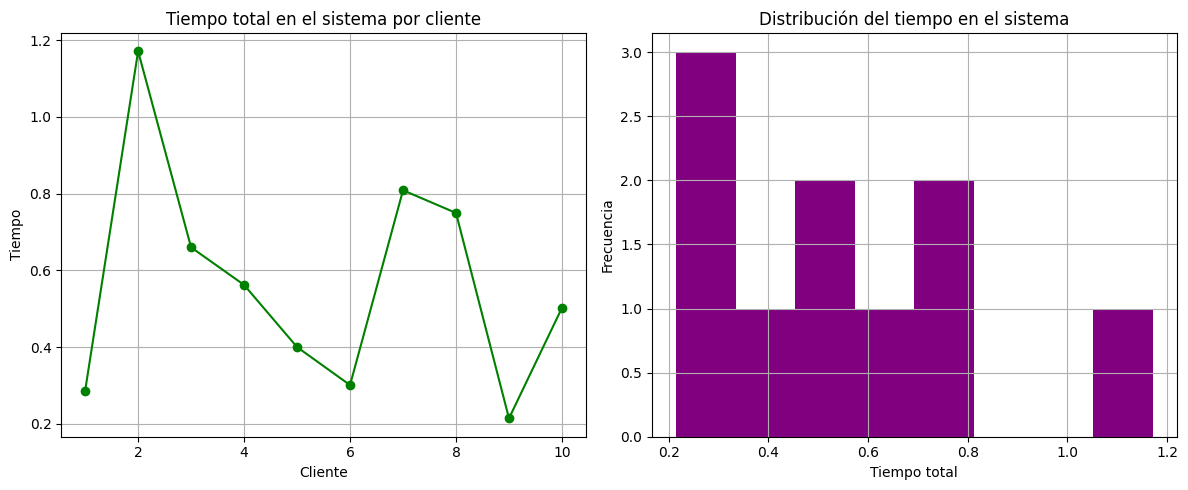

In [475]:
clientes = list(T.keys())
tiempos = list(T.values())

# Crear figura con dos gráficas
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Tiempo total por cliente
ax[0].plot(
    clientes,
    tiempos,
    marker='o',
    color='green'
)

ax[0].set_title('Tiempo total en el sistema por cliente')
ax[0].set_xlabel('Cliente')
ax[0].set_ylabel('Tiempo')
ax[0].grid(True)

# Histograma de tiempos totales
ax[1].hist(
    tiempos,
    bins=8,
    color='purple'
)

ax[1].set_title('Distribución del tiempo en el sistema')
ax[1].set_xlabel('Tiempo total')
ax[1].set_ylabel('Frecuencia')
ax[1].grid(True)

# Ajustar diseño

plt.tight_layout()
plt.show()

Se observa que los tiempos de permanencia se concentran en valores bajos, con pocos clientes presentando tiempos más elevados.

**Conclusión**

Se simuló correctamente un sistema de dos servidores en serie utilizando el algoritmo de eventos discretos de Ross.

A partir de los tiempos de llegada y salida fue posible calcular el tiempo de permanencia de cada cliente dentro del sistema. Además, las gráficas permitieron visualizar la variabilidad de estos tiempos y comprender mejor el comportamiento general de la línea de espera.

## Sistema de línea de espera con dos servidores en paralelo

**Objetivo:** Analizar el comportamiento de una línea de espera con dos servidores en paralelo mediante simulación de eventos discretos, registrando los tiempos de permanencia de los clientes dentro del sistema y evaluando el desempeño de cada servidor.*texto en cursiva*

###Fundamento teorico

Consideremos un sistema de dos servidores en paralelo al que los clientes llegan de acuerdo con un proceso de Poisson.

Cuando un cliente llega al sistema:

- Si el servidor 1 está libre, entra inmediatamente a servicio con dicho servidor.
- En caso contrario, si el servidor 2 está libre, entra a servicio con el servidor 2.
- Si ambos servidores están ocupados, el cliente se incorpora a una cola de espera.

Cuando un cliente concluye su servicio en cualquiera de los dos servidores, abandona el sistema. Si existen clientes esperando en la cola, el primero de ellos entra inmediatamente al servidor que quedó libre.

Este modelo corresponde a una línea de espera con dos servidores en paralelo.



**Variable de tiempo**:
$t$

**Variable de estado del sistema (ES)**

$$(n,i_1,i_2,\ldots,i_n)$$

donde:

- $n$ es el número de clientes presentes en el sistema.
- $i_1$ es el cliente atendido por el servidor 1.
- $i_2$ es el cliente atendido por el servidor 2.
- Los clientes restantes representan la cola de espera.

**Variables de conteo**

- $N_A$: número de llegadas hasta el instante $t$.

- $C_1$: número de servicios completados por el servidor 1 hasta el instante $t$.

- $C_2$: número de servicios completados por el servidor 2 hasta el instante $t$.

**Variables de salida**

- $A(n)$: hora de llegada del cliente $n$.

- $D(n)$: hora de salida del cliente $n$.

**Lista de eventos**

La lista de eventos está formada por:

$$
t_A,\; t_1,\; t_2
$$

donde:

- $t_A$ es la hora de la siguiente llegada.
- $t_1$ es la hora de finalización del servicio en el servidor 1.
- $t_2$ es la hora de finalización del servicio en el servidor 2.

Si un servidor se encuentra desocupado, se considera:

$$
t_i=\infty,
\qquad i=1,2.
$$

In [476]:
import numpy as np
from dataclasses import dataclass
from collections import deque
import matplotlib.pyplot as plt

Crearemos una estructura de datos para almacenar el estado del sistema durante la simulación.

Además, utilizaremos una cola (`deque`) para representar la fila de espera de los clientes cuando ambos servidores se encuentren ocupados.

Esta representación sigue la lógica propuesta por Ross para la simulación mediante eventos discretos.

In [477]:
# Estado del sistema

@dataclass
class EstadoSistema:

    # Número de llegadas
    NA: int = 0

    # Servicios completados por cada servidor
    C1: int = 0
    C2: int = 0

    # Tiempo actual
    t: float = 0.0

    # Cliente atendido por servidor 1
    servidor1: int = 0

    # Cliente atendido por servidor 2
    servidor2: int = 0

## Generación de tiempos aleatorios

Se reutilizarán las funciones:

- `generar_llegada(lamb)`
- `generar_servicio1(mu1)`
- `generar_servicio2(mu2)`

definidas previamente en la sección de línea de espera con dos servidores en serie, ya que las llegadas continúan modelándose mediante un proceso de Poisson y los tiempos de servicio de ambos servidores siguen distribuciones exponenciales con parámetros $\mu_1$ y $\mu_2$, respectivamente.

*Inicialización*

Se establecen las condiciones iniciales del sistema. Inicialmente no hay clientes en servicio ni en la cola de espera.

Además, se considera la primera llegada al sistema y los tiempos de terminación de servicio se toman infinitos, ya que ambos servidores comienzan desocupados.

In [478]:
def inicializar(lamb):
    """
    Inicializa las variables del sistema.
    """

    # Crear estado inicial
    estado = EstadoSistema()

    # Cola de espera vacía
    cola = deque()

    # Programar primera llegada
    tA = generar_llegada(lamb)

    # Servidores inicialmente desocupados
    t1 = np.inf
    t2 = np.inf

    return estado, cola, tA, t1, t2

*Caso 1: Llegada de un cliente*

Cuando un cliente llega al sistema se registra su hora de llegada y se programa la siguiente llegada.

Si alguno de los servidores se encuentra disponible, el cliente inicia servicio inmediatamente. En caso contrario, se incorpora al final de la cola de espera.

In [479]:
# Caso 1: Llegada de un cliente

def evento_llegada(estado, cola, tA, t1, t2,
                   lamb, mu1, mu2, A):
    """
    Procesa una llegada al sistema.
    """

    # Actualizar reloJ
    estado.t = tA

    # Registrar llegada
    estado.NA += 1

    cliente = estado.NA

    A[cliente] = estado.t

    # Consederar siguiente llegada
    tA = estado.t + generar_llegada(lamb)

    # Servidor 1 libre
    if estado.servidor1 == 0:

        estado.servidor1 = cliente

        y1 = generar_servicio1(mu1)

        t1 = estado.t + y1

    # Servidor 2 libre
    elif estado.servidor2 == 0:

        estado.servidor2 = cliente

        y2 = generar_servicio2(mu2)

        t2 = estado.t + y2

    # Ambos ocupados: cliente a la cola
    else:
        cola.append(cliente)

    return tA, t1, t2

*Caso 2: Terminación de servicio en el servidor 1*

Cuando un cliente finaliza su servicio en el servidor 1, abandona el sistema y se registra su hora de salida.

Si existen clientes esperando en la cola, el primero de ellos ocupa inmediatamente el servidor 1 y se considera  la siguiente terminación de servicio

In [480]:
# Caso 2: Terminación de servicio en servidor 1

def evento_servidor1(estado, cola, tA, t1, t2,
                     mu1, D):
    """
    Cliente termina servicio en el servidor 1.
    """

    # Actualizar reloj
    estado.t = t1

    # Registrar servicio completado
    estado.C1 += 1

    # Cliente que abandona el sistema
    cliente = estado.servidor1

    D[cliente] = estado.t

    # Revisar cola de espera
    if len(cola) == 0:

        estado.servidor1 = 0

        t1 = np.inf

    else:

        siguiente = cola.popleft()

        estado.servidor1 = siguiente

        y1 = generar_servicio1(mu1)

        t1 = estado.t + y1

    return tA, t1, t2

*Caso 3: Terminación de servicio en el servidor 2*

Cuando un cliente finaliza su servicio en el servidor 2, abandona el sistema y se registra su hora de salida.

Si existen clientes esperando en la cola, el primero de ellos entra inmediatamente al servidor 2 y se considera la siguiente terminación de servicio.

In [481]:
# Caso 3: Terminación de servicio en servidor 2

def evento_servidor2(estado, cola, tA, t1, t2,
                     mu2, D):
    """
    Cliente termina servicio en el servidor 2.
    """

    # Actualizar reloj
    estado.t = t2

    # Registrar servicio completado
    estado.C2 += 1

    # Cliente que abandona el sistema
    cliente = estado.servidor2

    D[cliente] = estado.t

    # Revisar cola de espera
    if len(cola) == 0:

        estado.servidor2 = 0

        t2 = np.inf

    else:

        siguiente = cola.popleft()

        estado.servidor2 = siguiente

        y2 = generar_servicio2(mu2)

        t2 = estado.t + y2

    return tA, t1, t2

**Función principal de simulación**

En cada iteración se identifica el evento más próximo y se ejecuta la rutina correspondiente hasta completar el número deseado de clientes.

In [482]:
def simular_paralelo(lamb, mu1, mu2, n_clientes):
    """
    Simulación de una línea de espera
    con dos servidores en paralelo.
    """

    # Inicializar sistema

    estado, cola, tA, t1, t2 = inicializar(lamb)

    # Diccionarios de llegadas y salidas
    A = {}
    D = {}

    # Ejecutar simulación
    while len(D) < n_clientes:

        # Próximo evento
        minimo = min(tA, t1, t2)

        # Caso 1: llegada
        if minimo == tA:

            tA, t1, t2 = evento_llegada(
                estado,
                cola,
                tA,
                t1,
                t2,
                lamb,
                mu1,
                mu2,
                A
            )

        # Caso 2: salida servidor 1
        elif minimo == t1:

            tA, t1, t2 = evento_servidor1(
                estado,
                cola,
                tA,
                t1,
                t2,
                mu1,
                D
            )

        # Caso 3: salida servidor 2
        else:

            tA, t1, t2 = evento_servidor2(
                estado,
                cola,
                tA,
                t1,
                t2,
                mu2,
                D
            )

    return A, D

In [483]:
# ejecucion
np.random.seed(123)

A, D = simular_paralelo(
    lamb=2,
    mu1=3,
    mu2=4,
    n_clientes=10
)

**Resultados obtenidos**

Se mostrarán los tiempos registrados para cada cliente durante la simulación y se presentan los instantes de llegada al sistema y los instantes de salida correspondientes.

In [484]:
# Tabla de eventos registrados

tabla = []

for cliente in A.keys():

    tabla.append([
        cliente,
        round(A[cliente], 4),
        round(D[cliente], 4)
    ])

print(
    tabulate(
        tabla,
        headers=[
            "Cliente",
            "Llegada",
            "Salida"
        ],
        tablefmt="github"
    )
)

|   Cliente |   Llegada |   Salida |
|-----------|-----------|----------|
|         1 |    0.5961 |   0.6819 |
|         2 |    0.7647 |   1.1884 |
|         3 |    1.1654 |   2.1531 |
|         4 |    1.4404 |   1.659  |
|         5 |    2.0178 |   2.1579 |
|         6 |    2.2666 |   2.4591 |
|         7 |    2.9196 |   3.0887 |
|         8 |    2.9503 |   3.0007 |
|         9 |    3.62   |   3.8728 |
|        10 |    3.7165 |   3.968  |


**Cálculo de estadísticas**

Con los tiempos de llegada y salida registrados se puede calcular el tiempo total que cada cliente permanece dentro del sistema.

Este tiempo incluye tanto la espera en cola como el tiempo de servicio.

In [485]:
# Tiempo total en el sistema
T = {
    n: D[n] - A[n]
    for n in D
}

In [486]:
print(
    "Tiempo promedio en sistema:",
    np.mean(list(T.values()))
)

Tiempo promedio en sistema: 0.2772203539544465


Y después hacemos la tabla de tiempos totales

In [487]:
# Tabla de tiempos en el sistema

tabla_tiempos = []

for cliente in sorted(T.keys()):

    tabla_tiempos.append([
        cliente,
        round(T[cliente], 4)
    ])

print(
    tabulate(
        tabla_tiempos,
        headers=[
            "Cliente",
            "Tiempo en sistema"
        ],
        tablefmt="github"
    )
)

|   Cliente |   Tiempo en sistema |
|-----------|---------------------|
|         1 |              0.0858 |
|         2 |              0.4237 |
|         3 |              0.9877 |
|         4 |              0.2186 |
|         5 |              0.1401 |
|         6 |              0.1924 |
|         7 |              0.1692 |
|         8 |              0.0504 |
|         9 |              0.2528 |
|        10 |              0.2516 |


Los resultados muestran el tiempo total que cada cliente permaneció en el sistema. Se aprecia una variabilidad natural entre clientes debido a la aleatoriedad de las llegadas y de los tiempos de servicio. Para esta simulación, la mayoría de los clientes fueron atendidos rápidamente, por lo que no se observan tiempos de espera excesivos.

## Análisis gráfico

Para complementar los resultados obtenidos se presentan dos gráficas.

- La primera muestra el tiempo total que cada cliente permaneció en el sistema.

- La segunda presenta la distribución de dichos tiempos mediante un histograma, permitiendo visualizar la variabilidad observada durante la simulación.

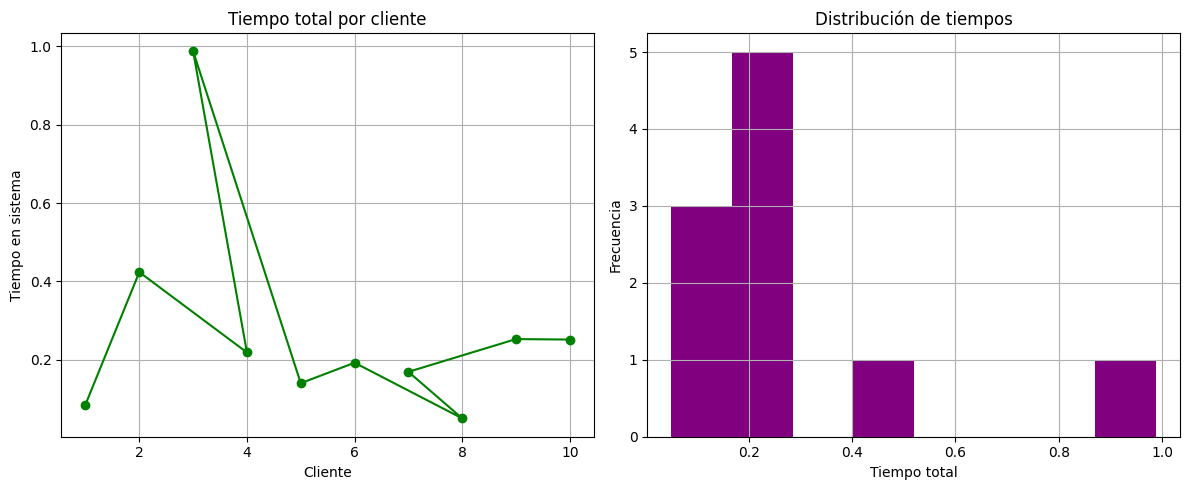

In [488]:
# Datos para las gráficas
clientes = list(T.keys())
tiempos = list(T.values())

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# Tiempo total por cliente
ax[0].plot(
    clientes,
    tiempos,
    marker='o',
    color='green'
)

ax[0].set_title('Tiempo total por cliente')
ax[0].set_xlabel('Cliente')
ax[0].set_ylabel('Tiempo en sistema')
ax[0].grid(True)

# Histograma
ax[1].hist(
    tiempos,
    bins=8,
    color='purple'
)

ax[1].set_title('Distribución de tiempos')
ax[1].set_xlabel('Tiempo total')
ax[1].set_ylabel('Frecuencia')
ax[1].grid(True)

plt.tight_layout()
plt.show()

La mayoría de los clientes permanecieron poco tiempo en el sistema, mientras que unos cuantos presentaron tiempos mayores. El histograma muestra que los tiempos pequeños son los más frecuentes, reflejando un sistema con baja congestión durante la simulación.

**Grafica. Evolución del número de clientes en el sistema**

Además del tiempo individual de cada cliente, resulta útil analizar cómo cambia la cantidad de clientes presentes en el sistema a lo largo del tiempo.

La siguiente gráfica muestra la evolución del número de clientes conforme ocurren llegadas y salidas durante la simulación.

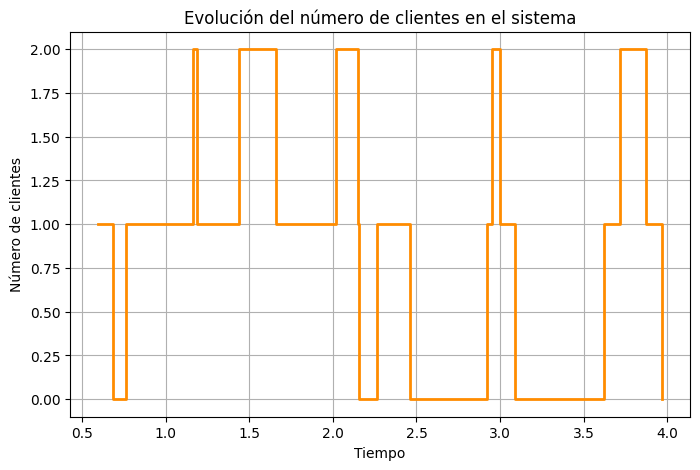

In [489]:
# Evolución del número de clientes en el sistema

tiempos_evento = []
clientes_sistema = []

n = 0

# Llegadas (+1)
for t in A.values():
    tiempos_evento.append((t, 1))

# Salidas (-1)
for t in D.values():
    tiempos_evento.append((t, -1))

# Ordenar cronológicamente
tiempos_evento.sort()

for tiempo, cambio in tiempos_evento:
    n += cambio
    clientes_sistema.append(n)

tiempos = [evento[0] for evento in tiempos_evento]

plt.figure(figsize=(8,5))

plt.step(
    tiempos,
    clientes_sistema,
    where='post',
    color='darkorange',
    linewidth=2
)

plt.xlabel('Tiempo')
plt.ylabel('Número de clientes')
plt.title('Evolución del número de clientes en el sistema')
plt.grid(True)

plt.show()

Se observa que el número de clientes en el sistema cambia conforme ocurren llegadas y salidas. Durante la simulación no se presentó una congestión elevada, ya que la cantidad de clientes permaneció en valores bajos la mayor parte del tiempo.

**Conclusión**

Se simuló correctamente una línea de espera con dos servidores en paralelo. Los resultados muestran que la atención simultánea de los servidores permitió mantener bajos los tiempos de permanencia y evitar una acumulación importante de clientes en el sistema.